# Portage Lake Volcanics ca. 1092 Ma paleomagnetic pole

## Geologic context

The Portage Lake Volcanics (PLV) are the thick succession of subaerial flood
basalts of the Keweenaw Peninsula, Michigan, erupted in the main magmatic stage
of the Midcontinent Rift and recording the Portage Lake normal-polarity zone. The
flows dip uniformly toward the rift axis as a homocline and are separated by
interflow conglomerates and sandstones, including the thick Great Conglomerate
and Conglomerate No. 16 that serve as stratigraphic markers. Two prominent thick
flows -- the Greenstone Flow and the Kearsarge Flow -- were sampled at many sites.

The succession is bracketed by U-Pb \(^{206}\)Pb/\(^{238}\)U dates of
1093.37 \(\pm\) 0.53 Ma on the Copper City Flow (near the base of the sampled
section) and 1091.59 \(\pm\) 0.27 Ma on the Greenstone Flow (Swanson-Hysell et al.,
2019), placing the pole at ca. 1092 Ma.

## Pole

The pole reproduces the site-level result of Swanson-Hysell et al. (2019),
combining the site VGPs of Books (1972) and Hnat et al. (2006). Four thick or
heavily-sampled cooling units -- the Kearsarge, Greenstone, Scales Creek, and
Ashbed flows -- are each reduced to a single combined VGP so that an individual
flow is not over-represented in the mean (one VGP per cooling unit). The
remaining flows contribute their individual site VGPs. The Greenstone Flow
combination also incorporates the data of Foucher et al. (2018).

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data and stratigraphic flow groups

Site tables from Books (1972) and Hnat et al. (2006) supply per-site VGPs;
Foucher et al. (2018) Greenstone Flow data are tilt-corrected and VGPs computed.
Flows are grouped by stratigraphic position relative to the Copper City (CC),
Greenstone (GS), and Conglomerate No. 16 markers.

In [2]:
CB = '../data/1092_Portage_Lake_Volcanics/contribution_build/'

books = pd.read_csv(CB + 'Books1972_PLV_sites_source.txt', sep='\t', header=1)
books['citations'] = 'Books, 1972'
# Books (1972) reports no site-level Fisher statistics; assign the study-mean k/a95
books_dir = ipmag.fisher_mean(books['dir_dec'].tolist(), books['dir_inc'].tolist())
books['dir_k'] = round(books_dir['k'], 1)
books['dir_alpha95'] = round(books_dir['alpha95'], 1)

hnat = pd.read_csv(CB + 'Hnat2006_PLV_sites_source.txt', sep='\t', header=1)
hnat['citations'] = 'Hnat et al., 2006'

foucher = pd.read_csv(CB + 'Foucher2018_Greenstone_sites_source.txt', sep='\t', header=1)
foucher = foucher[foucher['dir_tilt_correction'] == 100.0].reset_index(drop=True)
foucher = ipmag.vgp_calc(foucher, tilt_correction='yes', dec_tc='dir_dec',
                         inc_tc='dir_inc', site_lon='lon', site_lat='lat')
foucher['citations'] = 'Foucher et al., 2018'

print(f'Books (1972): {len(books)} flow sites; Hnat et al. (2006): {len(hnat)} sites; '
      f'Foucher et al. (2018): {len(foucher)} Greenstone sites')

Books (1972): 69 flow sites; Hnat et al. (2006): 28 sites; Foucher et al. (2018): 0 Greenstone sites


In [3]:
# --- stratigraphic flow groups (Books 1972 site ids) ------------------------
CCtoGS = ['PL343','PL61','PL325','PL60','PL58','PL57','PL327','PL326','PL56','PL55',
          'PL324','PL53','PL323','PL52','PL330','PL51','PL344','PL331','PL50','PL150',
          'PL1','PL3','PL6','PL5','PL4','PL7','PL35','PL158','PL160','PL159','PL157',
          'PL154','PL153']                              # CC->GS, individual flows
GS_16   = ['PL8','PL9','PL10','PL11','PL12','PL13','PL14','PL19','PL20','PL22','PL24',
           'PL25','PL26','PL27']                        # GS->Conglomerate No. 16
top16   = ['PL49','PL333','PL44']                       # above Conglomerate No. 16
# thick / heavily-sampled cooling units, each combined to ONE VGP:
Kearsarge = ['PL54','PL335']; Scales = ['PL59','PL341']
GS_books  = ['PL34','PL33','PL32','PL345','PL346','PL347','PL348','PL349']
Ashbed    = ['PL329','PL43','PL340','PL338','PL339','PL342']

# --- Hnat et al. (2006) groups ---------------------------------------------
H_bottom_CC = ['H_PL10','H_PL17']
H_CC_GS = ['H_PL15','H_PL21','H_PL13','H_PL11','H_PL06','H_PL04','H_PL03','H_PL02',
           'H_PL01','H_PL08','H_PL24','H_PL25','H_PL19','H_PL26','H_PL27','H_PL28',
           'H_PL29','H_PL30','H_PL31','H_PL32']
H_GS_top = ['H_PL22','H_PL23','H_PL07','H_PL05','H_PL12']
H_GS = ['H_PL14','H_PL16','H_PL20']

pick = lambda df, ids: df[df['site'].isin(ids)].reset_index(drop=True)

### One combined VGP per thick cooling unit

The Kearsarge, Greenstone, Scales Creek, and Ashbed flows are each represented by
a single Fisher-mean VGP (and mean direction). The Greenstone Flow mean combines
Books (1972), Hnat et al. (2006), and Foucher et al. (2018) site data.

In [4]:
def combined_flow(name, books_ids, extra=None):
    grp = pick(books, books_ids)
    vlon = grp['vgp_lon'].tolist(); vlat = grp['vgp_lat'].tolist()
    ddec = grp['dir_dec'].tolist(); dinc = grp['dir_inc'].tolist()
    lat = grp['lat'].tolist(); lon = grp['lon'].tolist(); nsamp = grp['dir_n_samples'].sum()
    cite = 'Books, 1972'
    for df in (extra or []):
        vlon += df['vgp_lon'].tolist(); vlat += df['vgp_lat'].tolist()
        ddec += df['dir_dec'].tolist(); dinc += df['dir_inc'].tolist()
        lat += df['lat'].tolist(); lon += df['lon'].tolist()
    if extra:
        cite = 'Books, 1972:Hnat et al., 2006:Foucher et al., 2018'
    mvgp = ipmag.fisher_mean(dec=vlon, inc=vlat)
    mdir = ipmag.fisher_mean(dec=ddec, inc=dinc)
    return {'site': name, 'citations': cite, 'lat': np.mean(lat), 'lon': np.mean(lon),
            'dir_dec': mdir['dec'], 'dir_inc': mdir['inc'], 'dir_k': round(mdir['k'], 1),
            'dir_alpha95': round(mdir['alpha95'], 1), 'dir_n_samples': int(nsamp),
            'dir_tilt_correction': 100, 'dir_polarity': 'n', 'result_type': 'a',
            'vgp_lon': mvgp['dec'], 'vgp_lat': mvgp['inc']}   # store un-swapped

composite = pd.DataFrame([
    combined_flow('Kearsarge flow', Kearsarge),
    combined_flow('Greenstone flow', GS_books, extra=[pick(hnat, H_GS), foucher]),
    combined_flow('Scales Creek flow', Scales),
    combined_flow('Ashbed flow', Ashbed),
])
composite[['site', 'dir_dec', 'dir_inc', 'dir_n_samples', 'vgp_lon', 'vgp_lat']]

,site,dir_dec,dir_inc,dir_n_samples,vgp_lon,vgp_lat
0,Kearsarge flow,290.799565,32.959847,9,179.080604,27.136283
1,Greenstone flow,291.271634,34.674953,35,180.088096,28.262089
2,Scales Creek flow,289.116766,33.705800,9,180.896892,26.309106
3,Ashbed flow,288.347570,29.512108,25,179.441342,24.090310


## Combined Portage Lake Volcanics pole

Plon: 183.1  Plat: 27.1
Number of directions in mean (n): 79
Angular radius of 95% confidence (A_95): 2.4
Precision parameter (k) estimate: 44.7

Swanson-Hysell et al. (2019) site-level pole: 27.1 N, 183.1 E, A95 2.4, N=79


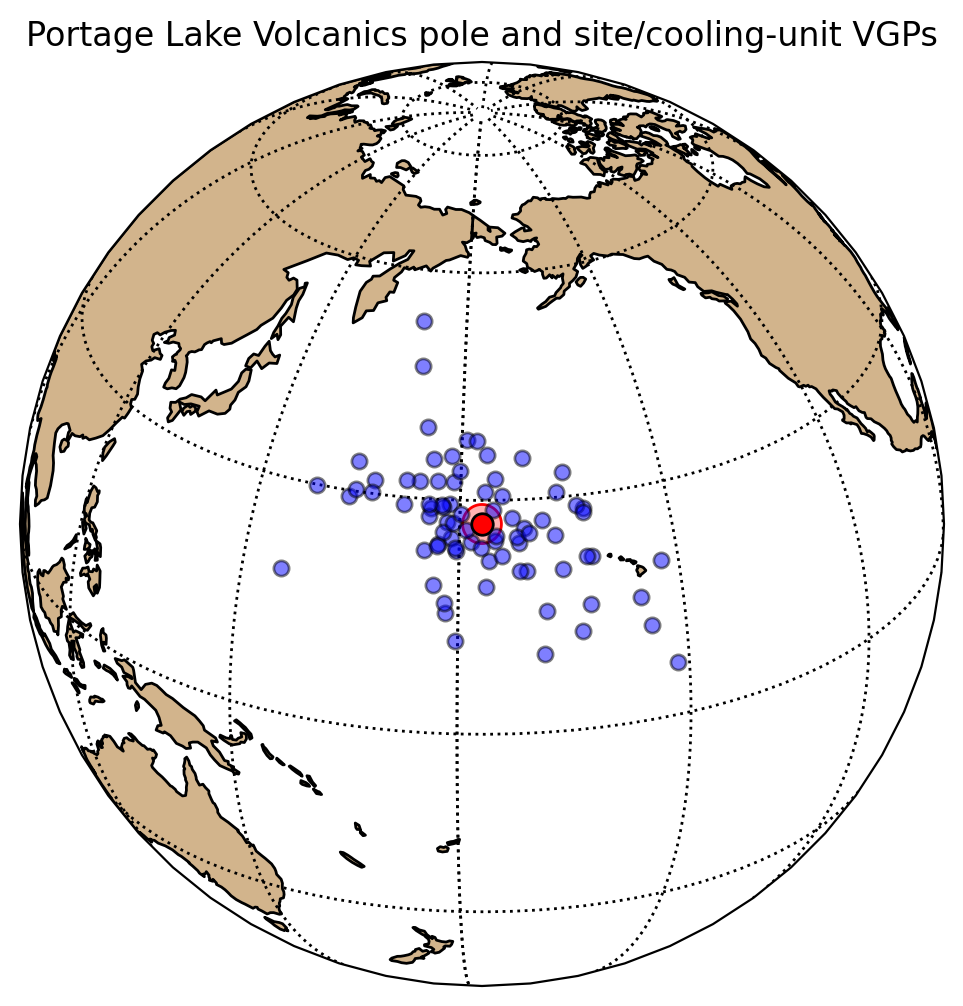

In [5]:
COMMON = ['site','citations','lat','lon','dir_dec','dir_inc','dir_k','dir_alpha95',
          'dir_n_samples','dir_tilt_correction','dir_polarity','vgp_lat','vgp_lon','result_type']

def harmonize(df, result_type='i'):
    out = pd.DataFrame()
    for c in COMMON:
        out[c] = df[c] if c in df.columns else np.nan
    out['result_type'] = out['result_type'].fillna(result_type)
    out['dir_polarity'] = out['dir_polarity'].fillna('n')
    out['dir_tilt_correction'] = 100
    return out

plv_sites = pd.concat([
    harmonize(pick(hnat, H_bottom_CC)), harmonize(pick(hnat, H_CC_GS)),
    harmonize(pick(hnat, H_GS_top)), harmonize(pick(books, CCtoGS)),
    harmonize(pick(books, GS_16)), harmonize(pick(books, top16)),
    harmonize(composite),
], ignore_index=True)

study_lat, study_lon = 47.29, 271.59   # SH2019 PLV reference locality
vgp_block, pole_mean = pt.compute_mean_pole(plv_sites, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print(f"\nSwanson-Hysell et al. (2019) site-level pole: 27.1 N, 183.1 E, A95 2.4, N=79")

_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Portage Lake Volcanics pole and site/cooling-unit VGPs')
plt.show()

## Mean direction (tilt-corrected)

Dec: 288.4  Inc: 36.1
Number of directions in mean (n): 79
Angular radius of 95% confidence (a_95): 2.6
Precision parameter (k) estimate: 38.3


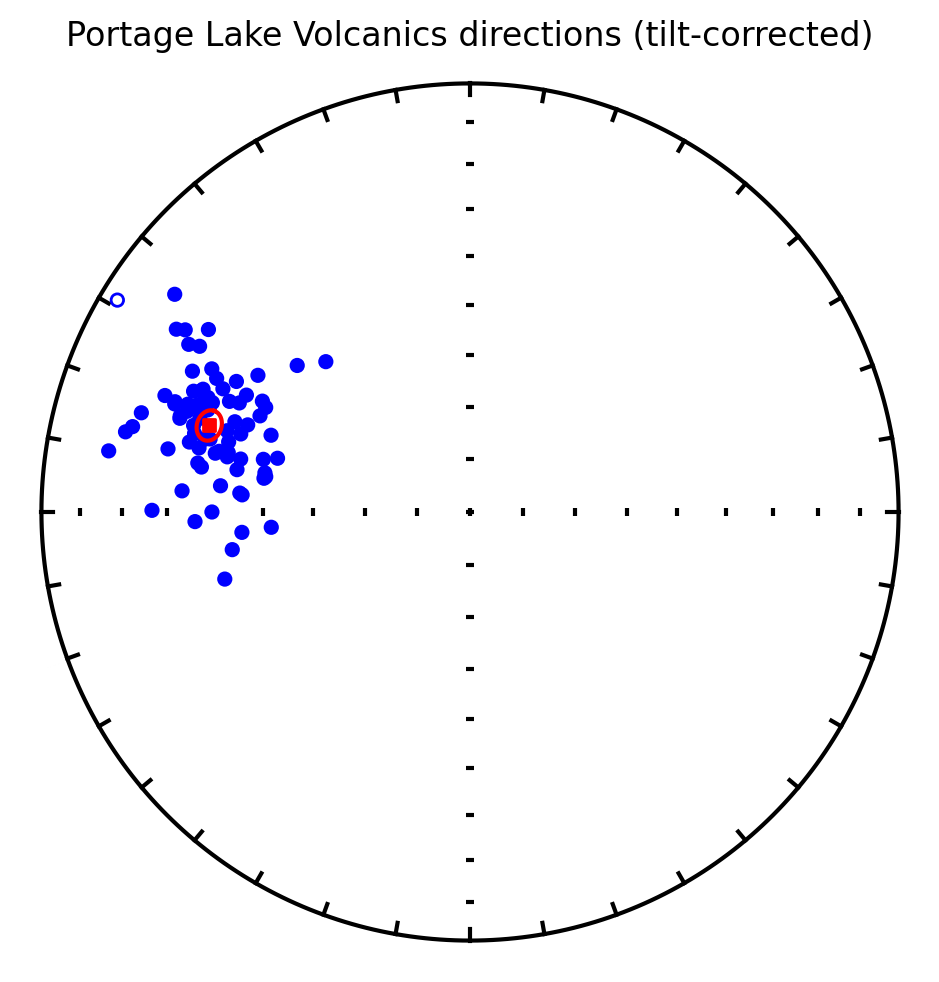

In [6]:
dir_block, dir_mean = pt.compute_mean_direction(plv_sites, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='red', marker='s')
plt.title('Portage Lake Volcanics directions (tilt-corrected)')
plt.show()

## Paleosecular variation and VGP-shape diagnostics

A_95 of 2.4 passes Deenen et al. (2011) criteria of being between 2.1 and 5.2 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

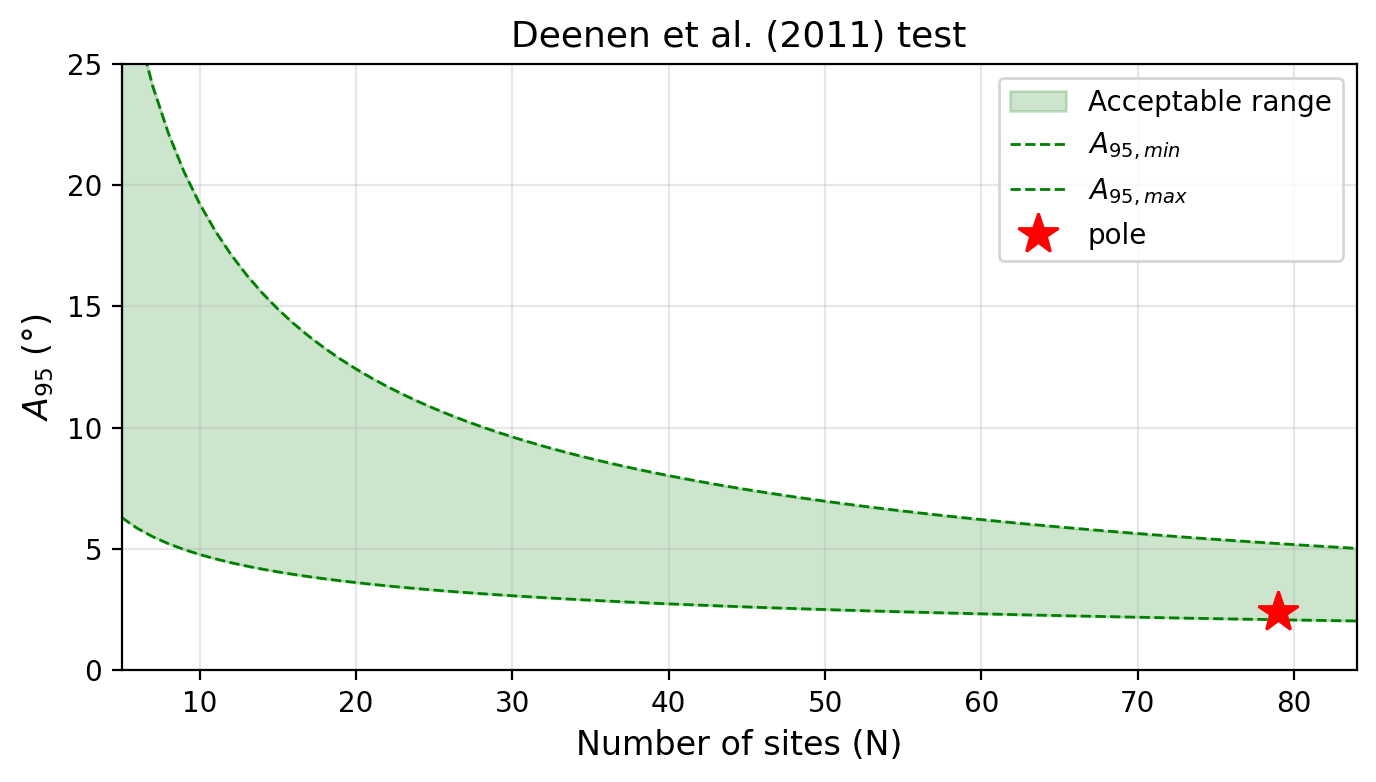

In [7]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

{'Mode': 'Mode 1',
 'Dec': 183.0450297491715,
 'Inc': 27.104381544717736,
 'N': 79,
 'Mu': 1.3032252123464176,
 'Mu_critical': 1.207,
 'Me': 1.1335554808468848,
 'Me_critical': 1.094,
 'Test_result': 'Fisher distribution rejected'}

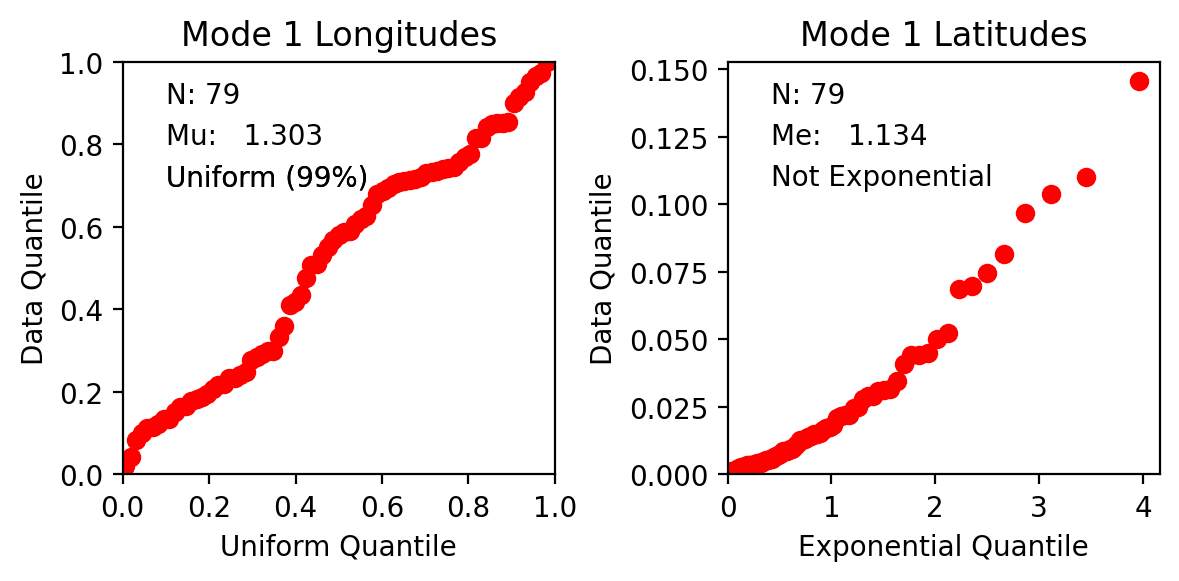

In [8]:
fishqq_result = pt.fishqq_vgps(plv_sites, unify_polarity=True)
fishqq_result

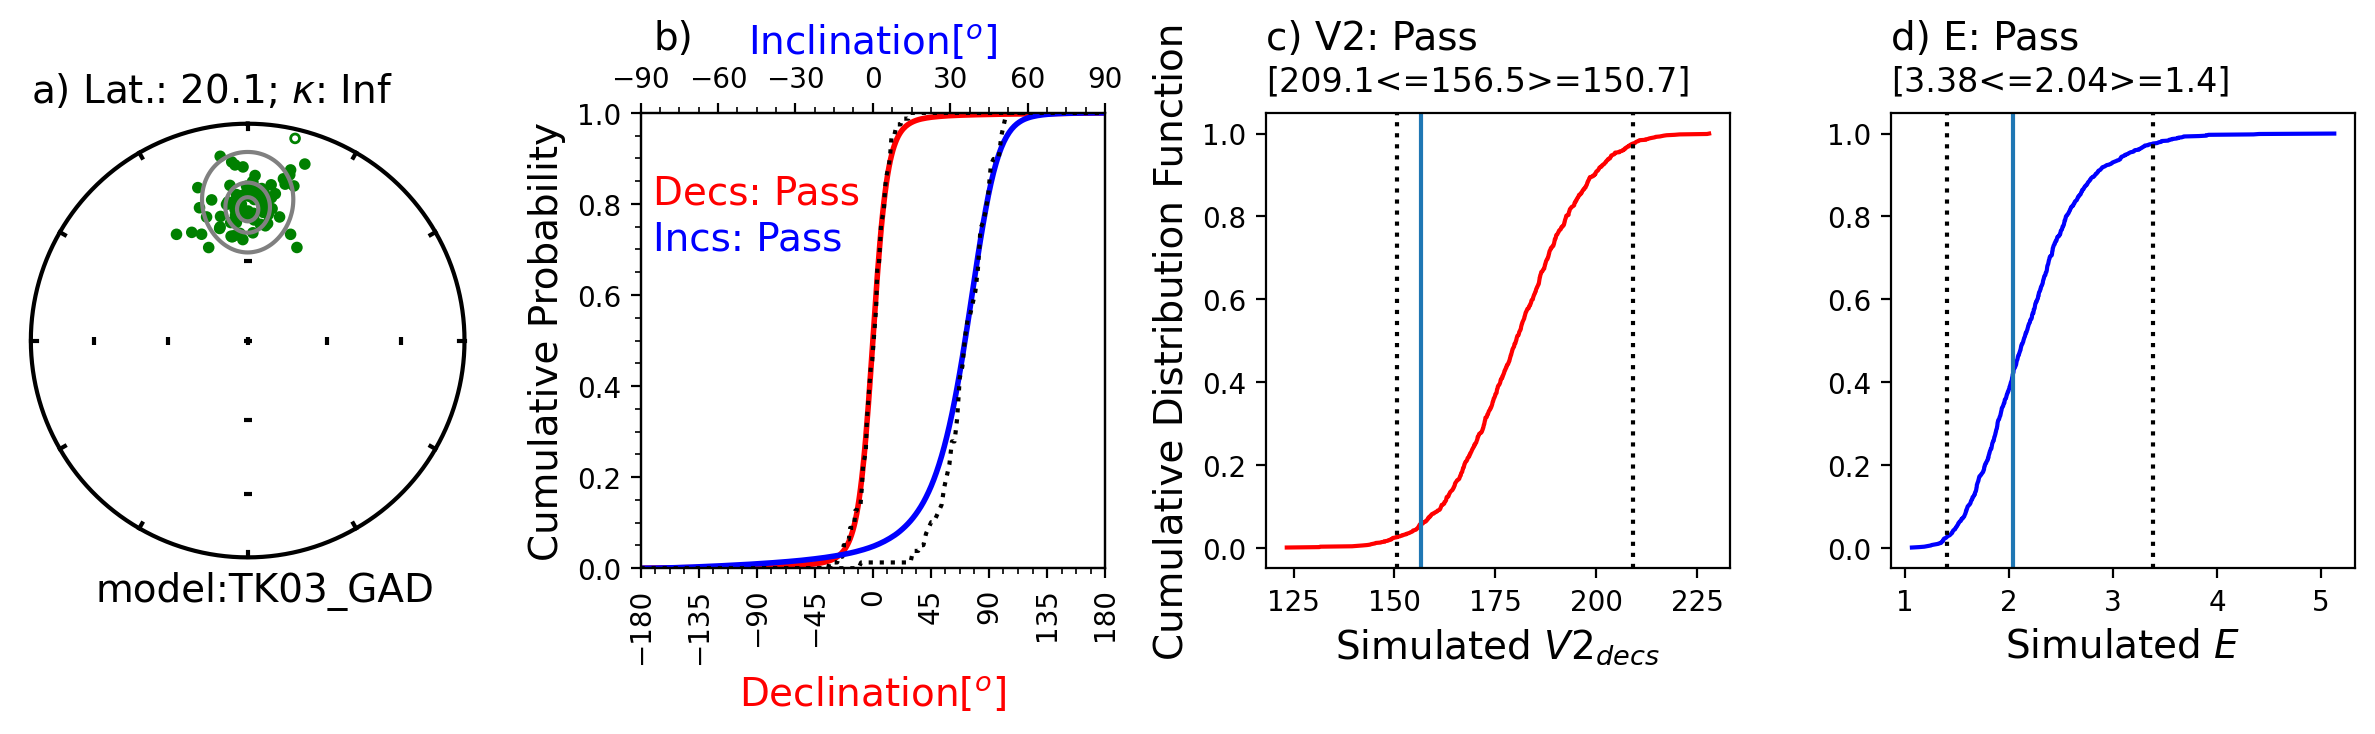

paleolatitude = 20.1 deg; elongation E = 2.04 (consistent with TK03.GAD)


In [9]:
svei_result = pt.svei_test_vgps(plv_sites, study_lon, study_lat,
                                model='TK03_GAD', plot=True)
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The PLV pole in the context of the Laurentia APWP

posx and posy should be finite values
posx and posy should be finite values


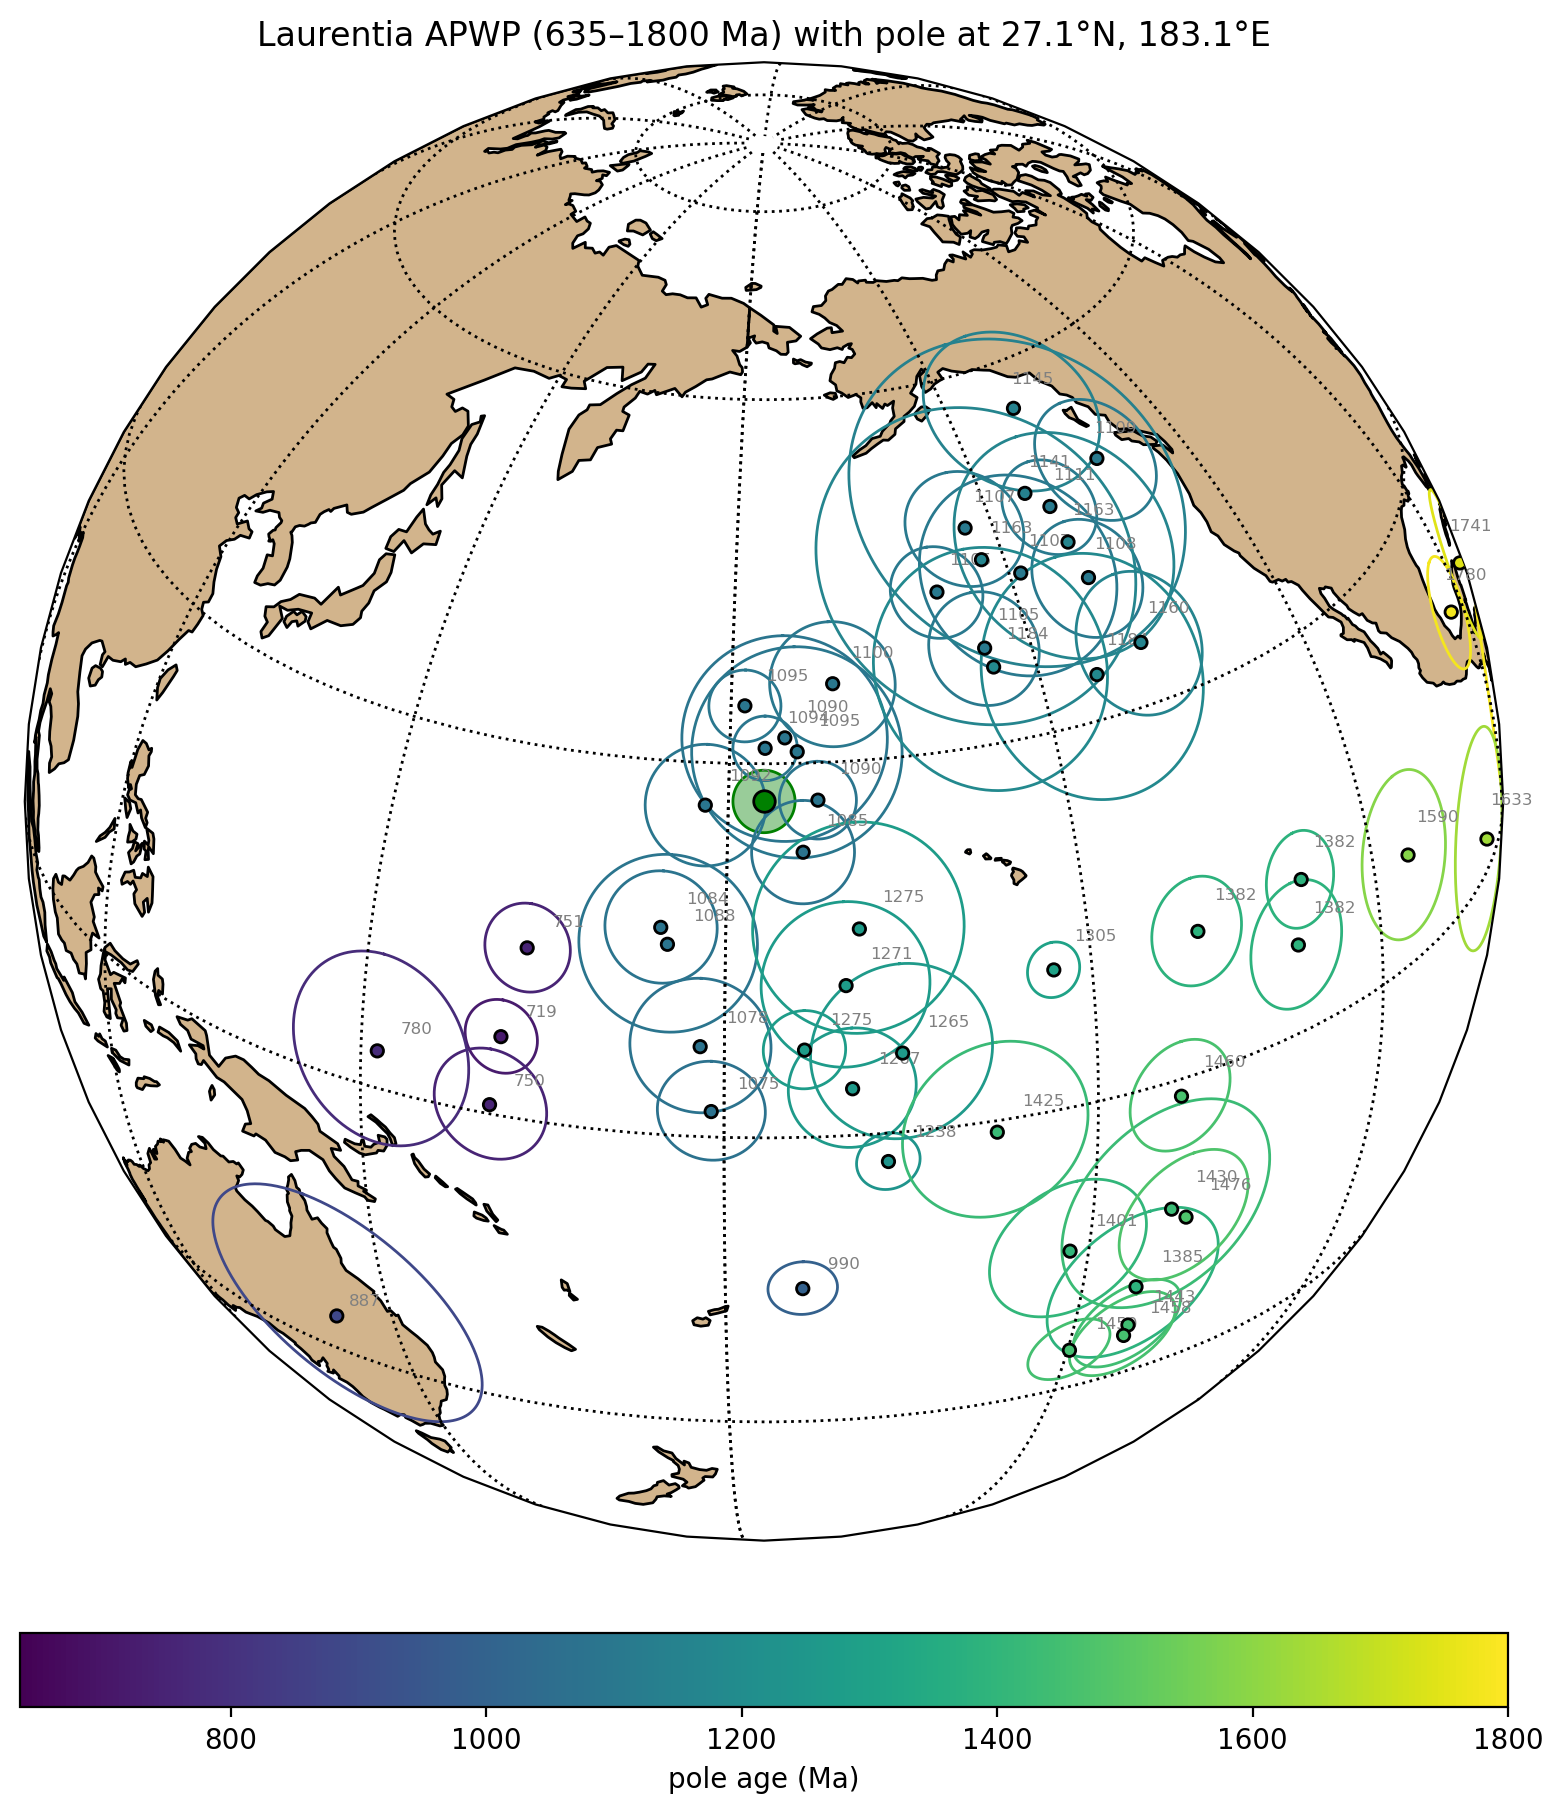

In [10]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

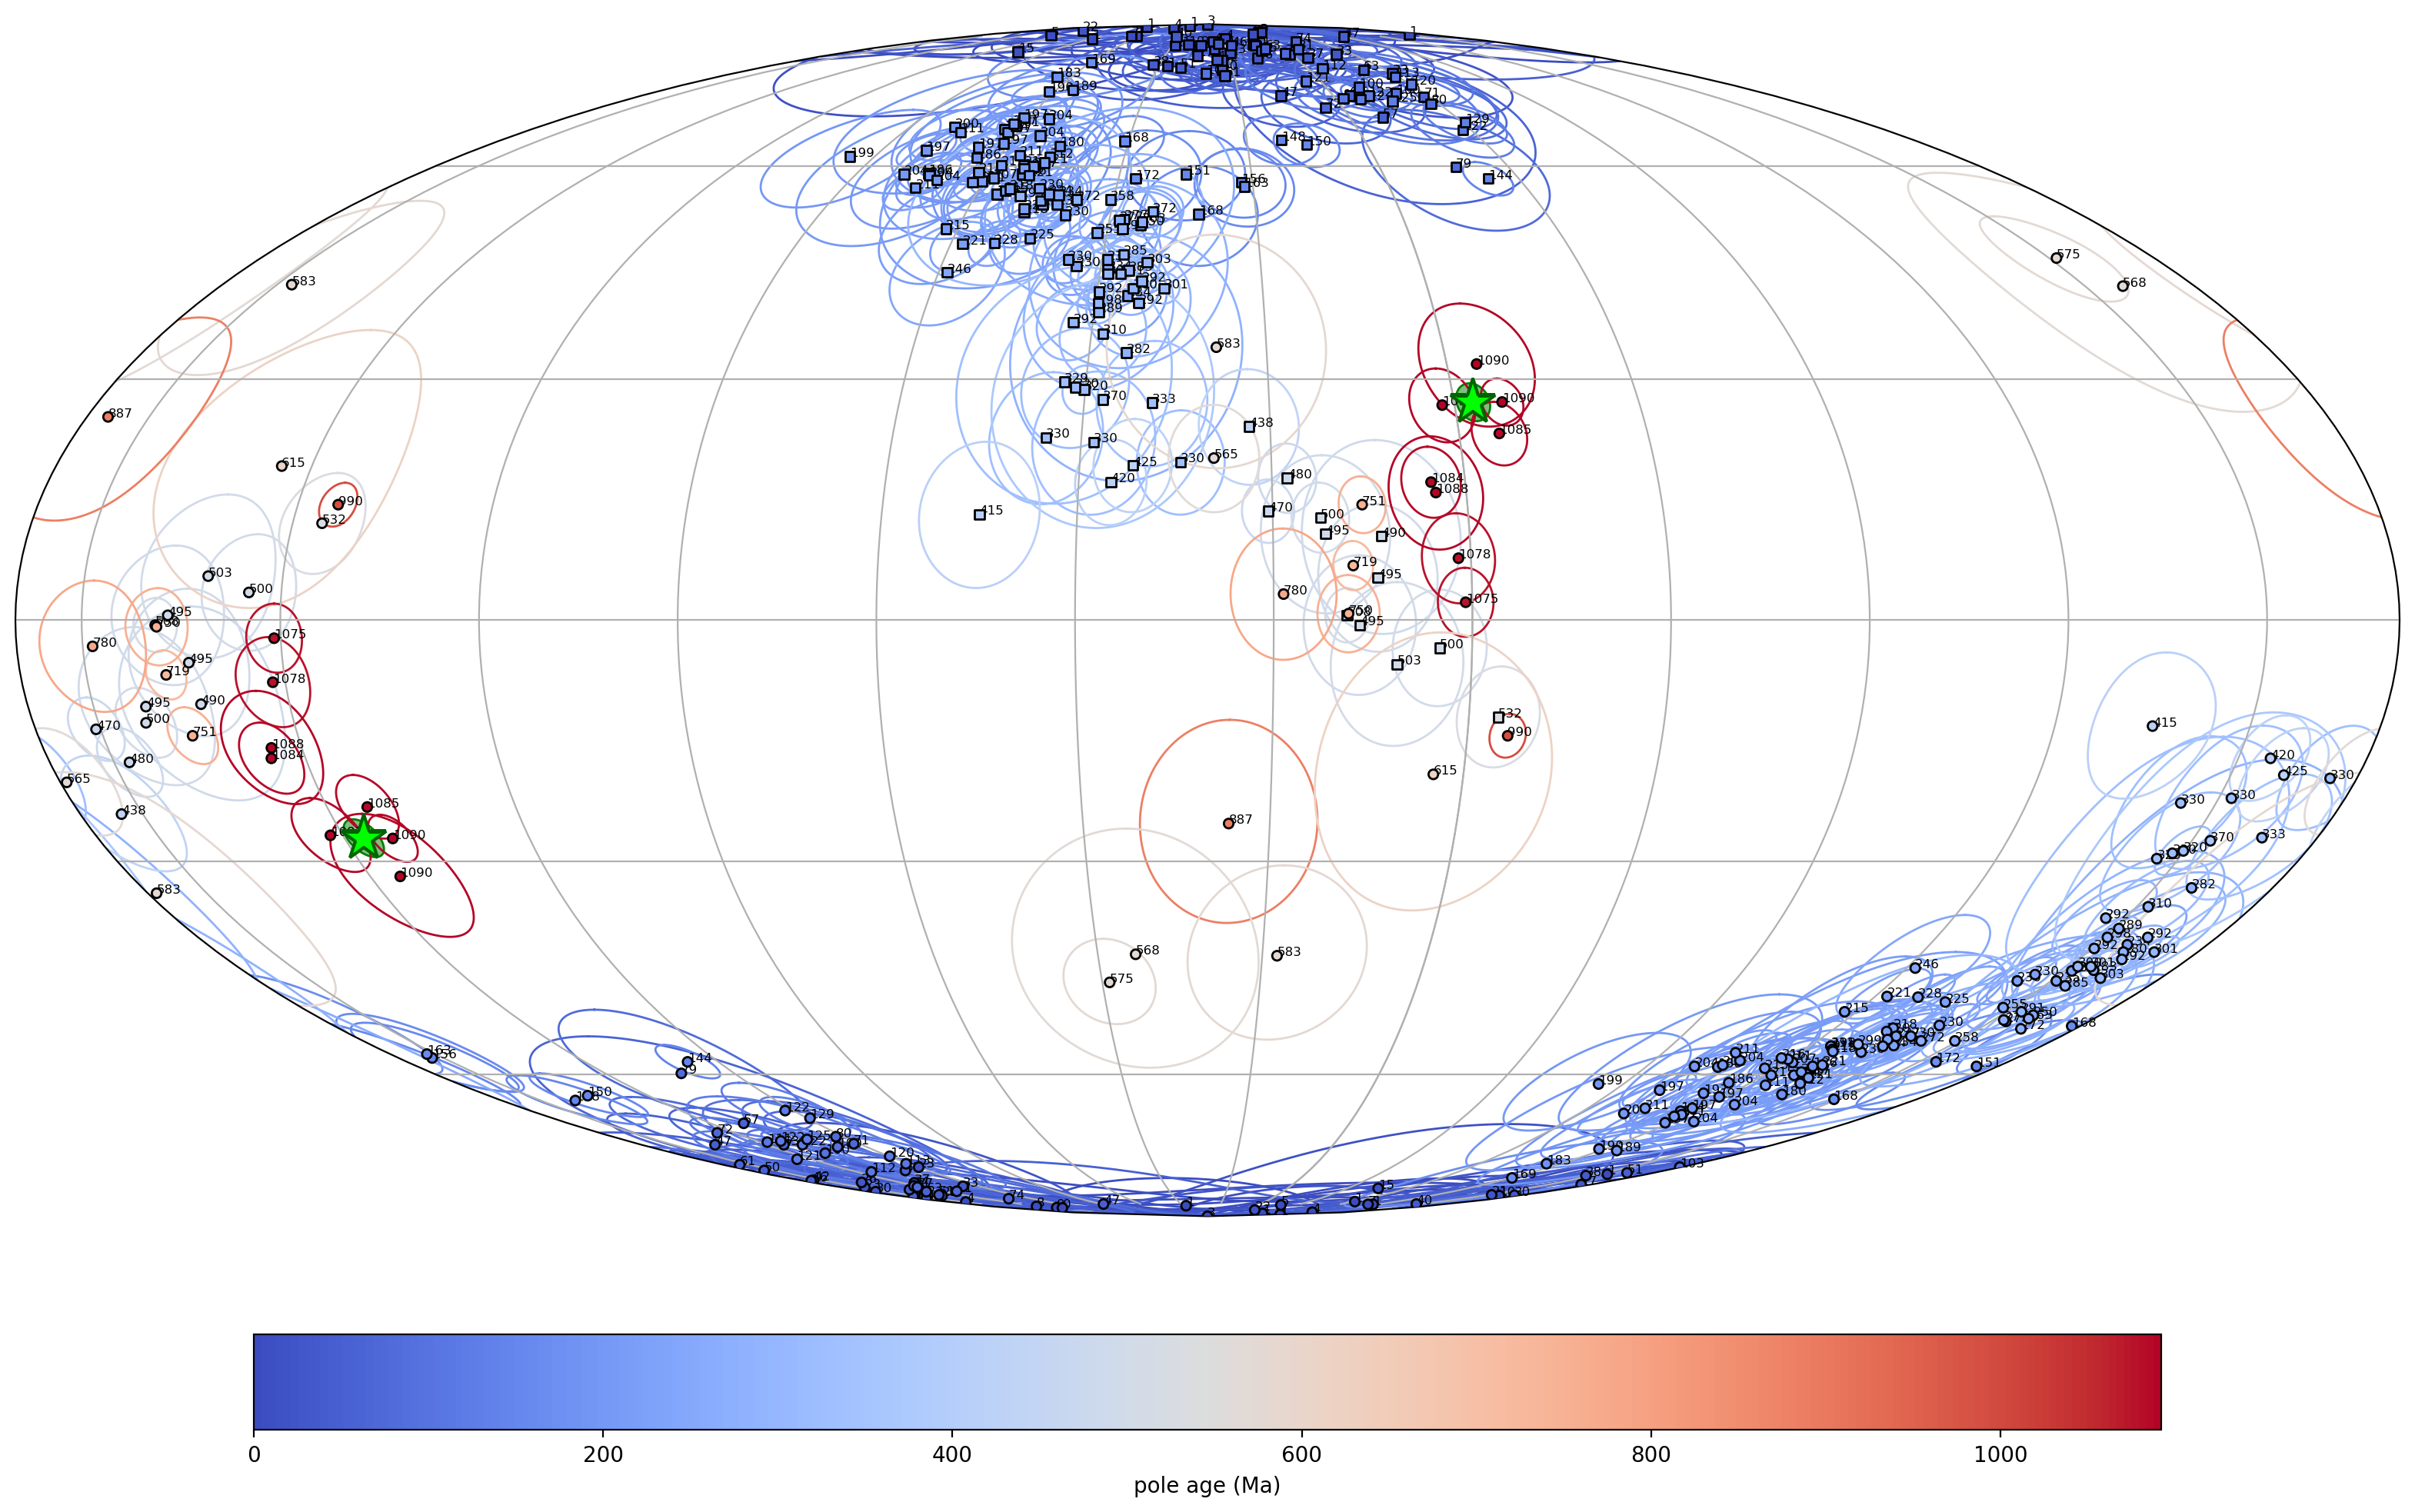

<GeoAxesSubplot:>

In [11]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Portage Lake Volcanics', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1092)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | ca. 1092 Ma, bracketed by U-Pb 206Pb/238U dates on the Copper City Flow (1093.37 ± 0.53 Ma) and the Greenstone Flow (1091.59 ± 0.27 Ma) (Swanson-Hysell et al., 2019). |
| 2 | Techniques and statistical analysis | **1** | AF demagnetization, PCA; N = 79 flow VGPs (thick cooling units combined to one VGP each), K = 44.7, A95 = 2.4° passes the Deenen et al. (2011) envelope. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence (Books, 1972; Hnat et al., 2006). |
| 4 | Field tests constrain age of magnetization | **Gf** | Positive intraformational conglomerate test on interflow Portage Lake conglomerates and a positive fold (curvature) test across the Keweenaw homocline (Books, 1972). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Keweenaw Peninsula homocline; tilt-corrected with interflow paleohorizontal. |
| 6 | Presence of reversals | **0** | Single (normal) polarity (Portage Lake normal-polarity zone). |
| 7 | No resemblance to younger poles | **1** | On the Keweenawan Track, distinct from younger Laurentia poles. |
| | Total | **6/7** | Grade A |

## Nordic workshop summary

The pole reproduces the Swanson-Hysell et al. (2019) site-level Portage Lake
Volcanics pole, updating the prior compilation entry (GPMDB 9507). Thick cooling
units (Kearsarge, Greenstone, Scales Creek, Ashbed) are each weighted as a single
VGP. The full sites-to-pole workflow is reproduced in this notebook.

In [12]:
# write the MagIC contribution (sites.txt + locations.txt)
OUT = '../data/1092_Portage_Lake_Volcanics/'
sites_out = plv_sites.copy()
sites_out['location'] = 'Portage Lake Volcanics'
sites_out['geologic_classes'] = 'Extrusive:Igneous'
sites_out['geologic_types'] = 'Lava Flow'
sites_out['lithologies'] = 'Basalt'
sites_out['result_quality'] = 'g'
sites_cols = ['location','site','citations','lat','lon','dir_dec','dir_inc','dir_k',
              'dir_alpha95','dir_n_samples','dir_tilt_correction','dir_polarity',
              'vgp_lat','vgp_lon','geologic_classes','geologic_types','lithologies',
              'result_type','result_quality']
with open(OUT + 'sites.txt', 'w') as f:
    f.write('tab\tsites\n')
sites_out[sites_cols].to_csv(OUT + 'sites.txt', sep='\t', index=False, mode='a')

loc_row = {'location': 'Portage Lake Volcanics', 'location_type': 'Region',
           'age': 1092, 'age_high': 1093.37, 'age_low': 1091.59, 'age_unit': 'Ma',
           'citations': 'Books, 1972:Hnat et al., 2006:Swanson-Hysell et al., 2019',
           'geologic_classes': 'Extrusive:Igneous', 'lithologies': 'Basalt',
           'lat_n': sites_out['lat'].max(), 'lat_s': sites_out['lat'].min(),
           'lon_e': sites_out['lon'].max(), 'lon_w': sites_out['lon'].min(),
           'dir_tilt_correction': 100, 'result_type': 'a', 'result_quality': 'g',
           'pole_lat': round(pole_mean['inc'], 1), 'pole_lon': round(pole_mean['dec'], 1),
           'pole_alpha95': round(pole_mean['alpha95'], 1), 'pole_k': round(pole_mean['k'], 1),
           'pole_n_sites': int(pole_mean['n']),
           'result_name': 'Portage Lake Volcanics normal-polarity pole'}
with open(OUT + 'locations.txt', 'w') as f:
    f.write('tab\tlocations\n')
pd.DataFrame([loc_row]).to_csv(OUT + 'locations.txt', sep='\t', index=False, mode='a')
print('wrote', OUT + 'sites.txt', 'and locations.txt')

wrote ../data/1092_Portage_Lake_Volcanics/sites.txt and locations.txt


In [13]:
plv_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Portage Lake Volcanics',
    sites=plv_sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization (magnetite); single normal polarity',
    tests='G*+ (positive intraformational conglomerate test on interflow conglomerates) and F+ (positive fold/curvature test across the Keweenaw homocline; Books, 1972)',
    gpmdb_number='9507',
    percent_reversed=0,
    demag_code=4,
    R1=1, R2=1, R3=1, R4='Gf', R5=1, R6=0, R7=1, Grade='A',
    nominal_age=1092, lomagage=1091.59, himagage=1093.37,
    REF_method='U-Pb 206Pb/238U dates on the Copper City Flow (1093.37 +/- 0.53 Ma) and Greenstone Flow (1091.59 +/- 0.27 Ma) bracket the sampled section (Swanson-Hysell et al., 2019).',
    POLE_AUTHORS='Books, K. G.; Hnat, J. S. et al.; compiled by Swanson-Hysell, N. L., Ramezani, J., Fairchild, L. M., & Rose, I. R.',
    YEAR=2019,
    JOURNAL='GSA Bulletin',
    VOLUME='131',
    VPAGES='913-940',
    TITLE='Failed rifting and fast drifting: Midcontinent Rift development, Laurentia rapid motion and the driver of Grenvillian orogenesis',
    COMMENT='Site-level Portage Lake Volcanics pole reproducing Swanson-Hysell et al. (2019), updating GPMDB 9507. Combines individual flow VGPs of Books (1972) and Hnat et al. (2006) with single combined VGPs for the thick Kearsarge, Greenstone (also Foucher et al., 2018), Scales Creek, and Ashbed cooling units so no flow is over-weighted (one VGP per cooling unit). N=79, reproduced 27.1N/183.1E, A95 2.4 in this notebook. Single normal polarity (R6=0).'
)
pt.save_nordic_summary(plv_summary, '1092_Portage_Lake_Volcanics')
plv_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Portage Lake Volcanics,GPMDB:9507,Characteristic remanent magnetization (magneti...,G*+ (positive intraformational conglomerate te...,100,47.29,271.59,79,481,...,1093,U-Pb 206Pb/238U dates on the Copper City Flow ...,Portage Lake Volcanics,"Books, K. G.; Hnat, J. S. et al.; compiled by ...",2019,GSA Bulletin,131,913-940,Failed rifting and fast drifting: Midcontinent...,Site-level Portage Lake Volcanics pole reprodu...
